In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [21]:
TABLES_DIR = Path("reports/tables")
FIGURES_DIR = Path("reports/figures")

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv("saudi_data_jobs_cleaned.csv")

df.head()

,job_id,job_title,company,city,role_type,experience_level,skills,tools,source,job_link,date_collected,notes,city_cleaned,experience_category,role_category
0,1,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analyst,Entry level / 3 years,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Customer experience data analyst role in autom...,Jeddah,Entry Level,Data Analysis
1,2,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Scientist,Entry level / 2-5 years,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat...",LinkedIn,https://sa.linkedin.com/jobs/view/geological-d...,2026-06-30,Mining sector data science role. Focuses on ge...,Mahd Adh Dhahab,Entry Level,Data Science
2,3,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analyst,Entry level,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,...",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Entry-level data analyst role for Madinaty Sup...,Riyadh,Entry Level,Data Analysis
3,4,Analyst Pricing Analytics and Insights,Schneider Electric,Saudi Arabia,Business / Pricing Analytics,Entry level,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports",LinkedIn,https://sa.linkedin.com/jobs/view/analyst-pric...,2026-06-30,Entry-level pricing analytics role. Focuses on...,Not specified,Entry Level,Business / Financial Analytics
4,5,Power BI Developer,Acuative Middle East,Jeddah,BI / Power BI Developer,Mid-level,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power...",LinkedIn,https://sa.linkedin.com/jobs/view/power-bi-dev...,2026-06-30,Mid-level Power BI Developer role in Jeddah. F...,Jeddah,Not Specified,BI


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (45, 15)

Columns:
['job_id', 'job_title', 'company', 'city', 'role_type', 'experience_level', 'skills', 'tools', 'source', 'job_link', 'date_collected', 'notes', 'city_cleaned', 'experience_category', 'role_category']


In [22]:
skills_df = df[["job_id", "skills"]].copy()

skills_df.head()

,job_id,skills
0,1,"customer data analysis, operational performanc..."
1,2,"geological data management, data quality manag..."
2,3,"data analysis, insights generation, dashboardi..."
3,4,"pricing analytics, data analysis, data interpr..."
4,5,"Power BI dashboard development, business intel..."


In [23]:
skills_df["skills"] = skills_df["skills"].fillna("")

In [24]:
skills_df["skills"] = skills_df["skills"].str.split(",")

In [25]:
skills_df = skills_df.explode("skills")

skills_df.head()

,job_id,skills
0,1,customer data analysis
0,1,operational performance analysis
0,1,data accuracy
0,1,reporting
0,1,dashboarding


In [26]:
skills_df["skills"] = (
    skills_df["skills"]
    .str.strip()
    .str.lower()
)

In [27]:
skills_df = skills_df[
    skills_df["skills"] != ""
]

In [28]:
skill_mapping = {

    "data analytics": "data analysis",

    "dashboarding": "dashboard development",

    "powerbi": "power bi",

    "bi": "business intelligence",

    "ml": "machine learning"
}


skills_df["skills"] = (
    skills_df["skills"]
    .replace(skill_mapping)
)

In [29]:
skills_unique = skills_df.drop_duplicates(
    subset=["job_id", "skills"]
)

skills_unique.head()

,job_id,skills
0,1,customer data analysis
0,1,operational performance analysis
0,1,data accuracy
0,1,reporting
0,1,dashboard development


In [30]:
technical_keywords = [

    "sql",
    "python",
    "excel",
    "power bi",
    "tableau",

    "data analysis",
    "data visualization",

    "machine learning",
    "ai",

    "data governance",
    "data quality",
    "data validation",
    "data integrity",

    "dashboard development",

    "business intelligence",

    "statistics",

    "predictive analytics",

    "data modeling"
]

In [31]:
technical_skills = skills_unique[
    skills_unique["skills"].isin(technical_keywords)
]

technical_skills.head()

,job_id,skills
0,1,dashboard development
1,2,data analysis
1,2,predictive analytics
1,2,machine learning
1,2,data governance


In [32]:
top_technical_skills = (
    technical_skills["skills"]
    .value_counts()
    .reset_index()
)


top_technical_skills.columns = [

    "Technical_Skill",
    "Number_of_jobs"

]


top_technical_skills.head(15)

,Technical_Skill,Number_of_jobs
0,data analysis,15
1,dashboard development,14
2,data integrity,12
3,data governance,12
4,data validation,10
5,machine learning,6
6,data visualization,6
7,business intelligence,6
8,data quality,5
9,data modeling,2


In [33]:
top_technical_skills.to_csv(
    TABLES_DIR / "top_technical_skills.csv",
    index=False
)

In [34]:
top10 = top_technical_skills.head(10)

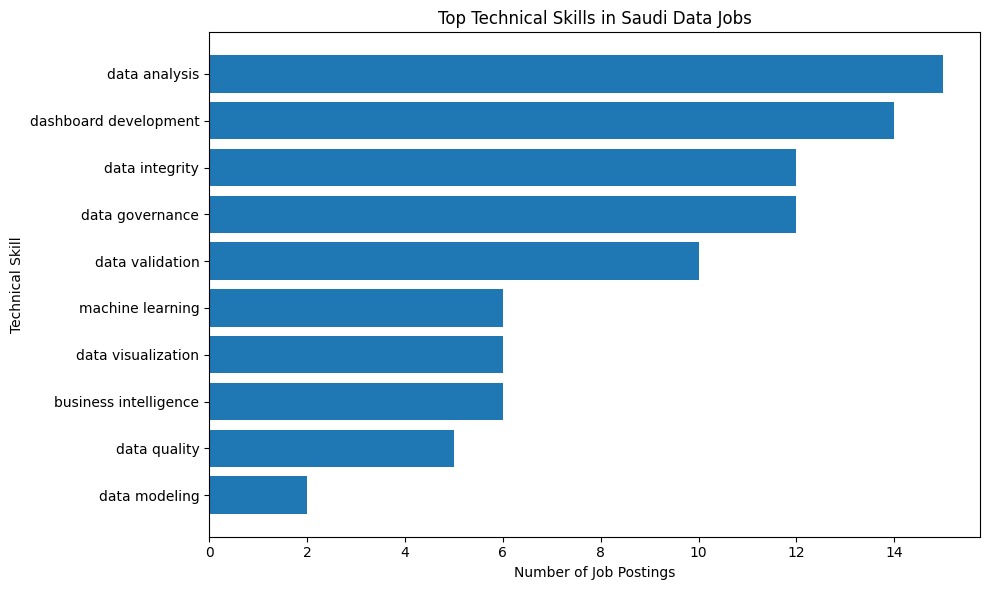

In [35]:
plt.figure(figsize=(10,6))


plt.barh(
    top10["Technical_Skill"],
    top10["Number_of_jobs"]
)


plt.xlabel("Number of Job Postings")

plt.ylabel("Technical Skill")


plt.title(
    "Top Technical Skills in Saudi Data Jobs"
)


plt.gca().invert_yaxis()


plt.tight_layout()


plt.savefig(
    FIGURES_DIR / "top_technical_skills.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [36]:
role_skill_analysis = technical_skills.merge(
    df[["job_id", "role_category"]],
    on="job_id",
    how="left"
)

In [37]:
role_skill_matrix = pd.crosstab(

    role_skill_analysis["skills"],

    role_skill_analysis["role_category"]

)


role_skill_matrix.head()

role_category,AI,BI,Business / Financial Analytics,Data Analysis,Data Science,Fraud Analytics,Governance,Marketing Analytics,Other,Performance Analytics,Research Analytics
skills,,,,,,,,,,,
business intelligence,0,4,0,0,1,0,1,0,0,0,0
dashboard development,1,4,1,4,1,0,0,1,0,2,0
data analysis,2,2,1,3,1,2,2,0,0,1,1
data governance,2,1,1,2,1,0,4,0,1,0,0
data integrity,0,0,0,2,1,0,3,0,1,3,2


In [38]:
role_skill_matrix.to_csv(
    TABLES_DIR / "technical_skills_by_role.csv"
)

## Day 22 Findings

The technical skills analysis identified the most frequently required technical capabilities in Saudi data-related job postings.

The results show that data analysis, data integrity, data governance, data validation, dashboard development, business intelligence, and machine learning are among the important technical skills required in the market.

The analysis will be used later to build a beginner and intermediate readiness roadmap for Computer Science students interested in data careers.

In [39]:
top_technical_skills.head(15)

,Technical_Skill,Number_of_jobs
0,data analysis,15
1,dashboard development,14
2,data integrity,12
3,data governance,12
4,data validation,10
5,machine learning,6
6,data visualization,6
7,business intelligence,6
8,data quality,5
9,data modeling,2
